#WEEK 3 EDA for Google Apps Review
irma@its.ac.id/ PBA 2025

In [1]:
from google.colab import files

# This will open a file upload dialog
uploaded = files.upload()

Saving df_cispdamrev.csv to df_cispdamrev.csv


In [6]:
import pandas as pd

# Assuming the uploaded file is named 'cispdamrev.csv'
# Adjust the filename if it's different (e.g., 'cispdamrev.xlsx' for Excel files)
file_name = list(uploaded.keys())[0] # Get the name of the uploaded file
df_cispdamrev = pd.read_csv(file_name)

print(f"File '{file_name}' uploaded and loaded successfully.")
display(df_cispdamrev.head())

File 'df_cispdamrev.csv' uploaded and loaded successfully.


/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")
/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,"e247ae20-d9e0-4dc0-9903-54af1569681f,Imelda Kr...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,cb66d30d-d518-4463-a4ed-3d558d6fea4c,Boby Gunawan,https://play-lh.googleusercontent.com/a-/ALV-U...,Upload versi terbaru tidak bisa di buka???,1.0,0.0,6.10.0,2026-03-04 03:55:16,NaN,NaN,6.10.0
2,6f0c8d48-24db-461a-88ef-5a2811226961,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,untuk cek mandiri di bulan Maret ini tiba2 ngg...,3.0,2.0,6.10.0,2026-03-03 08:14:26,NaN,NaN,6.10.0
3,"cd93882a-3425-46eb-995d-275106d1f2dc,ardyan no...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,05bb3a43-d1af-4f69-8157-ec1ae63c6c3e,Hendra Gunawan,https://play-lh.googleusercontent.com/a-/ALV-U...,ini app kenapa tidak bisa login ya? dibuka han...,1.0,1.0,6.10.0,2026-02-26 02:21:40,NaN,NaN,6.10.0


In [13]:
nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Exploratory Data Analysis (EDA) of CIS PDAM Surabaya Reviews

## 1. Install Necessary Packages
This section ensures that all required Python packages are installed before running the notebook.
```python
!pip install pandas matplotlib seaborn nltk
```

In [7]:
!pip install pandas matplotlib seaborn nltk

## 2. Import Required Libraries
We import essential libraries for data analysis, visualization, and text processing.
```python
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import nltk
import string
```

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import nltk
import string

## 3. Download Stopwords
Downloading the Indonesian stopwords from NLTK for text processing.
```python
nltk.download('stopwords')
from nltk.corpus import stopwords
```

In [9]:
import pandas as pd

# Get the name of the uploaded file
file_name = list(uploaded.keys())[0]
df_cispdamrev = pd.read_csv(file_name)

print(f"File '{file_name}' uploaded and loaded successfully.")
display(df_cispdamrev.head())

File 'df_cispdamrev.csv' uploaded and loaded successfully.


/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")
/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,"e247ae20-d9e0-4dc0-9903-54af1569681f,Imelda Kr...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,cb66d30d-d518-4463-a4ed-3d558d6fea4c,Boby Gunawan,https://play-lh.googleusercontent.com/a-/ALV-U...,Upload versi terbaru tidak bisa di buka???,1.0,0.0,6.10.0,2026-03-04 03:55:16,NaN,NaN,6.10.0
2,6f0c8d48-24db-461a-88ef-5a2811226961,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,untuk cek mandiri di bulan Maret ini tiba2 ngg...,3.0,2.0,6.10.0,2026-03-03 08:14:26,NaN,NaN,6.10.0
3,"cd93882a-3425-46eb-995d-275106d1f2dc,ardyan no...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,05bb3a43-d1af-4f69-8157-ec1ae63c6c3e,Hendra Gunawan,https://play-lh.googleusercontent.com/a-/ALV-U...,ini app kenapa tidak bisa login ya? dibuka han...,1.0,1.0,6.10.0,2026-02-26 02:21:40,NaN,NaN,6.10.0


In [10]:
!pip install Sastrawi

import re
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from nltk.stem import WordNetLemmatizer
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')


# Create stemmer and lemmatizer objects
factory = StemmerFactory()
stemmer = factory.create_stemmer()
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    # Convert non-string types (like float/NaN) to empty string
    if not isinstance(text, str):
        return ''

    # Case lowering
    text = text.lower()

    # Punctuation removal
    text = re.sub(r'[^\w\s]', '', text)

    # Stemming
    text = stemmer.stem(text)

    # Lemmatization (requires a part-of-speech tag for optimal results, using 'v' for verb as a default)
    words = text.split()
    lemmatized_words = [lemmatizer.lemmatize(word, 'v') for word in words]
    text = ' '.join(lemmatized_words)

    return text

# Apply the cleaning function to the 'content' column of df_cispdamrev
df_cispdamrev['cleaned_review'] = df_cispdamrev['content'].apply(clean_text)

# Display the DataFrame with the cleaned reviews
print(df_cispdamrev[['content', 'cleaned_review']].head())

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


                                             content  \
0                                                NaN   
1         Upload versi terbaru tidak bisa di buka???   
2  untuk cek mandiri di bulan Maret ini tiba2 ngg...   
3                                                NaN   
4  ini app kenapa tidak bisa login ya? dibuka han...   

                                      cleaned_review  
0                                                     
1               upload versi baru tidak bisa di buka  
2  untuk cek mandiri di bulan maret ini tiba2 ngg...  
3                                                     
4  ini app kenapa tidak bisa login ya buka hanya ...  


## 5. Data Overview
This section provides basic dataset information, including column names, data types, and the first few records.
```python
# Convert 'at' column to datetime format
df_jknrev['at'] = pd.to_datetime(df_jknrev['at'])

# Display dataset info and first few rows
df_jknrev.info()
df_jknrev.head()
```

In [11]:
# Convert 'at' column to datetime format
df_cispdamrev['at'] = pd.to_datetime(df_cispdamrev['at'])

# Display dataset info and first few rows
df_cispdamrev.info()
df_cispdamrev.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewId              398 non-null    object        
 1   userName              242 non-null    object        
 2   userImage             242 non-null    object        
 3   content               241 non-null    object        
 4   score                 242 non-null    float64       
 5   thumbsUpCount         242 non-null    float64       
 6   reviewCreatedVersion  221 non-null    object        
 7   at                    242 non-null    datetime64[ns]
 8   replyContent          24 non-null     object        
 9   repliedAt             24 non-null     object        
 10  appVersion            221 non-null    object        
 11  cleaned_review        398 non-null    object        
dtypes: datetime64[ns](1), float64(2), object(9)
memory usage: 37.4+ KB


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,cleaned_review
0,"e247ae20-d9e0-4dc0-9903-54af1569681f,Imelda Kr...",NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,
1,cb66d30d-d518-4463-a4ed-3d558d6fea4c,Boby Gunawan,https://play-lh.googleusercontent.com/a-/ALV-U...,Upload versi terbaru tidak bisa di buka???,1.0,0.0,6.10.0,2026-03-04 03:55:16,NaN,NaN,6.10.0,upload versi baru tidak bisa di buka
2,6f0c8d48-24db-461a-88ef-5a2811226961,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,untuk cek mandiri di bulan Maret ini tiba2 ngg...,3.0,2.0,6.10.0,2026-03-03 08:14:26,NaN,NaN,6.10.0,untuk cek mandiri di bulan maret ini tiba2 ngg...
3,"cd93882a-3425-46eb-995d-275106d1f2dc,ardyan no...",NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,
4,05bb3a43-d1af-4f69-8157-ec1ae63c6c3e,Hendra Gunawan,https://play-lh.googleusercontent.com/a-/ALV-U...,ini app kenapa tidak bisa login ya? dibuka han...,1.0,1.0,6.10.0,2026-02-26 02:21:40,NaN,NaN,6.10.0,ini app kenapa tidak bisa login ya buka hanya ...


## 6. Missing Values Analysis
Identifies and counts missing values in each column.
```python
missing_values = df_jknrev.isnull().sum()
print("Missing Values Summary:")
print(missing_values)
```

In [12]:
missing_values = df_cispdamrev.isnull().sum()
print("Missing Values Summary:")
print(missing_values)

Missing Values Summary:
reviewId                  0
userName                156
userImage               156
content                 157
score                   156
thumbsUpCount           156
reviewCreatedVersion    177
at                      156
replyContent            374
repliedAt               374
appVersion              177
cleaned_review            0
dtype: int64


## 7. Review Score Distribution
Visualizing the distribution of review scores to understand user sentiments.
```python
plt.figure(figsize=(8,5))
sns.countplot(x=df_jknrev['score'], palette="viridis")
plt.title("Distribution of Review Scores")
plt.xlabel("Review Score")
plt.ylabel("Count")
plt.show()
```

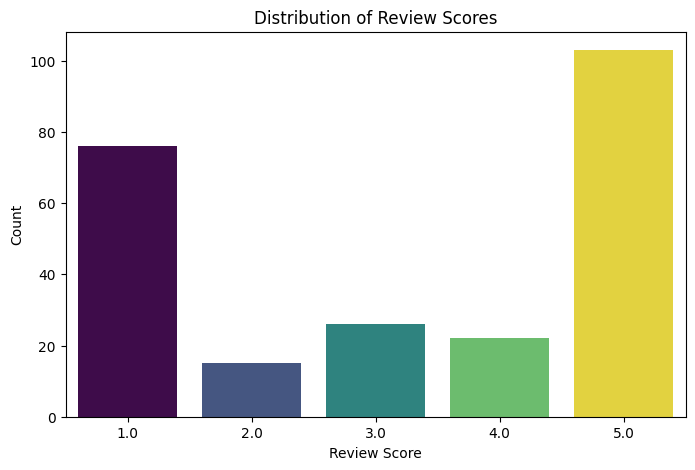

In [15]:
plt.figure(figsize=(8,5))
sns.countplot(x=df_cispdamrev['score'], hue=df_cispdamrev['score'], palette="viridis", legend=False)
plt.title("Distribution of Review Scores")
plt.xlabel("Review Score")
plt.ylabel("Count")
plt.show()

## 8. Review Trends Over Time
Analyzing how the number of reviews changes over time to detect patterns.
```python
# Extract review date
df_jknrev['review_date'] = df_jknrev['at'].dt.date
review_trend = df_jknrev.groupby('review_date').size()

plt.figure(figsize=(12, 6))
review_trend.plot()
plt.title("Daily Review Counts Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Reviews")
plt.grid(True)
plt.show()
```

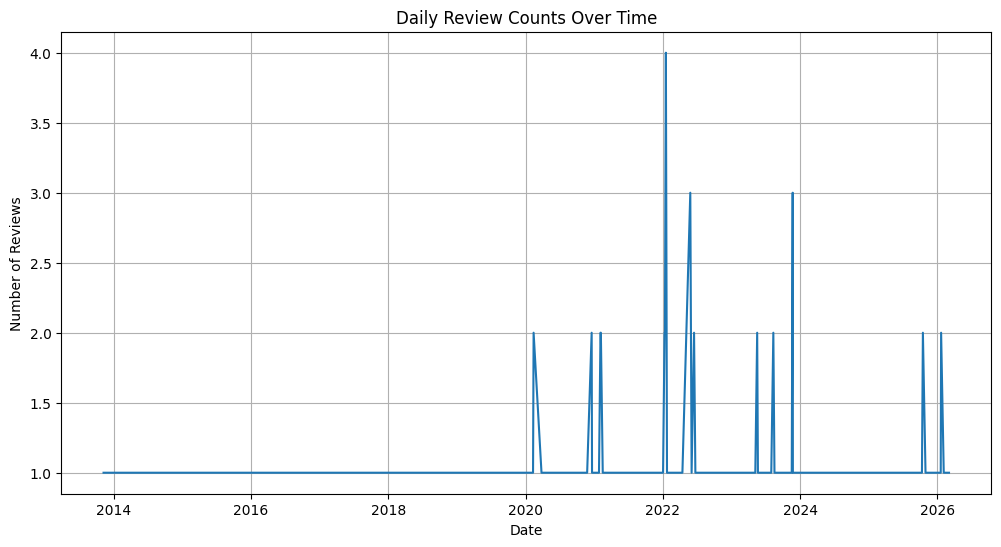

In [17]:
# Extract review date
df_cispdamrev['review_date'] = df_cispdamrev['at'].dt.date
review_trend = df_cispdamrev.groupby('review_date').size()

plt.figure(figsize=(12, 6))
review_trend.plot()
plt.title("Daily Review Counts Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Reviews")
plt.grid(True)
plt.show()

In [16]:
import nltk
from nltk.corpus import stopwords
from collections import Counter
import string

# Ensure 'stopwords' are downloaded
nltk.download('stopwords')

stop_words = set(stopwords.words('indonesian'))

# Combine all review text
# Dropping NaN values from 'content' before joining
all_reviews = " ".join(df_cispdamrev['content'].dropna()).lower()
all_reviews = all_reviews.translate(str.maketrans("", "", string.punctuation))

# Tokenization and filtering words
words = all_reviews.split()
filtered_words = [word for word in words if word not in stop_words]

# Counting word occurrences
word_counts = Counter(filtered_words)
common_words = pd.DataFrame(word_counts.most_common(20), columns=['Word', 'Frequency'])

# Display most common words
print("Most Common Words in Reviews:")
print(common_words)

Most Common Words in Reviews:
         Word  Frequency
0    aplikasi         23
1        good         21
2          ga         19
3        pdam         17
4       login         16
5         app         16
6       catat         16
7      update         15
8    membantu         14
9       meter         13
10  pelanggan         11
11         yg         10
12        and          9
13     jadwal          9
14        tdk          9
15    tagihan          9
16       buka          7
17         hp          7
18     respon          7
19         ok          7


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
